In [13]:
import json
import numpy as np
import pandas as pd

### Derriving mapping

In [14]:
with open("cfsort_full_map_dict.json", "rb") as f:
    tissue_mapping_dict = json.load(f)

In [15]:
def get_expected_cell_types(tissue_dict, threshold, exclude_keys=("unmapped",)):
    """
    Build a DataFrame of expected cell types per tissue based on a loyfer_counts
    percentage threshold.

    Parameters
    ----------
    tissue_dict : dict
        Dictionary keyed by tissue name (cfsort_name), with each value containing
        a 'loyfer_counts' sub-dict.
    threshold : float
        Minimum percentage (0-1 scale, e.g. 0.05 for 5%) a cell type must reach
        to be included in expected_cell_types.
    exclude_keys : tuple of str
        Keys to always exclude from consideration (default: ('unmapped',)).

    Returns
    -------
    pd.DataFrame
        Columns: cfsort_tissue_name, expected_cell_types, final_mapping_rate
    """
    rows = []
    for tissue_name, tissue_data in tissue_dict.items():
        loyfer_counts = tissue_data.get("loyfer_counts", {}) or {}

        # Filter out excluded keys before computing the total so percentages
        # are relative to the "mappable" pool. If you'd rather keep 'unmapped'
        # in the denominator, move this filtering to after the total is computed.
        filtered = {k: v for k, v in loyfer_counts.items() if k not in exclude_keys}

        total = sum(loyfer_counts.values())

        if total == 0:
            rows.append(
                {
                    "cfsort_tissue_name": tissue_name,
                    "expected_cell_types": [],
                    "final_mapping_rate": 0.0,
                }
            )
            continue

        # Build (cell_type, percentage) pairs and filter by threshold
        passing = [
            (ct, cnt / total)
            for ct, cnt in filtered.items()
            if (cnt / total) >= threshold
        ]

        # Sort by percentage descending for readability
        passing.sort(key=lambda x: x[1], reverse=True)

        expected_cell_types = [ct for ct, _ in passing]
        final_mapping_rate = round(sum(p for _, p in passing), 4)

        rows.append(
            {
                "cfsort_tissue_name": tissue_name,
                "expected_cell_types": expected_cell_types,
                "final_mapping_rate": final_mapping_rate,
            }
        )

    return pd.DataFrame(
        rows,
        columns=["cfsort_tissue_name", "expected_cell_types", "final_mapping_rate"],
    )

In [16]:
tissue_mapping_df = get_expected_cell_types(
    tissue_dict=tissue_mapping_dict, threshold=0.01
)
tissue_mapping_df = tissue_mapping_df[tissue_mapping_df["final_mapping_rate"] > 0.7]

### Processing results

In [17]:
uxm_results_path = (
    "/home/luna.kuleuven.be/u0169940/Repos/methyldl/EDA/cfSort_rrbs_uxm_results.csv"
)
uxm_results = pd.read_csv(uxm_results_path)
uxm_results["Biosample term name"] = uxm_results["Biosample term name"].apply(
    lambda x: x if x != "stom" else "stomach"
)
uxm_results = uxm_results[
    [
        "CellType",
        "file",
        "Biosample term name",
        "UXM_U25",
        "UXM_U25_LCal",
        "UXM_U250",
        "UXM_U25_GSC_Sorted",
    ]
]

In [18]:
methylbert_soft_results_path = "cfSort_rrbs_methylbert_soft_results.csv"
methylbert_soft_results = pd.read_csv(methylbert_soft_results_path)
methylbert_soft_results["Biosample term name"] = methylbert_soft_results[
    "Biosample term name"
].apply(lambda x: x if x != "stom" else "stomach")
methylbert_soft_results = methylbert_soft_results[
    [
        "CellType",
        "file",
        "Biosample term name",
        "XGB",
        "XGB_LCal",
        "MLP",
        "MLP_LCal",
        "SWN",
        "SWN_LCal",
        "NNLS",
        "NNLS_LCal",
        "PSLS",
        "PSLS_LCal",
    ]
]

In [19]:
import pandas as pd


def compute_on_target_proportions(
    deconv_df,
    expected_df,
    method_columns,
    biosample_col="Biosample term name",
    file_col="file",
    celltype_col="CellType",
):
    """
    Compute the proportion of predicted signal that falls on expected cell types,
    per file + biosample, for each specified deconvolution method.

    Parameters
    ----------
    deconv_df : pd.DataFrame
        Deconvolution results. Must contain `celltype_col`, `file_col`,
        `biosample_col`, and all columns listed in `method_columns`.
    expected_df : pd.DataFrame
        Output of `get_expected_cell_types`, with columns
        ['cfsort_tissue_name', 'expected_cell_types', 'final_mapping_rate'].
    method_columns : list of str
        Deconvolution method columns to evaluate, e.g. ['UXM_U25', 'UXM_U250'].
    biosample_col, file_col, celltype_col : str
        Column names in `deconv_df`.

    Returns
    -------
    pd.DataFrame
        One row per (file, biosample) with on-target proportions per method,
        plus the corresponding expected_cell_types and final_mapping_rate
        for reference.
    """
    # Accept a single method as a string too
    if isinstance(method_columns, str):
        method_columns = [method_columns]

    # Merge expected cell types onto each deconvolution row via the biosample.
    # Left join keeps deconv rows even if there's no expected mapping.
    merged = deconv_df.merge(
        expected_df,
        how="left",
        left_on=biosample_col,
        right_on="cfsort_tissue_name",
    )

    # Flag rows whose CellType is in the per-tissue expected list.
    # Handle NaN (missing mapping) and non-list values safely.
    def _is_on_target(row):
        expected = row["expected_cell_types"]
        if not isinstance(expected, list):
            return False
        return row[celltype_col] in expected

    merged["on_target"] = merged.apply(_is_on_target, axis=1)

    # For each method, on-target proportion = sum of proportions where on_target is True
    group_keys = [file_col, biosample_col]
    agg_rows = []

    for (file_id, biosample), grp in merged.groupby(group_keys, dropna=False):
        row = {file_col: file_id, biosample_col: biosample}

        # Carry over the expected list and final_mapping_rate (same within group)
        row["expected_cell_types"] = (
            grp["expected_cell_types"].iloc[0]
            if isinstance(grp["expected_cell_types"].iloc[0], list)
            else []
        )
        row["final_mapping_rate"] = grp["final_mapping_rate"].iloc[0]

        on_target_mask = grp["on_target"]
        for method in method_columns:
            on_target_sum = grp.loc[on_target_mask, method].sum()
            row[f"{method}"] = round(float(on_target_sum), 4)

        agg_rows.append(row)

    result = pd.DataFrame(agg_rows)

    # Nice column order
    method_cols_out = [f"{m}" for m in method_columns]
    result = result[
        [file_col, biosample_col, "expected_cell_types", "final_mapping_rate"]
        + method_cols_out
    ]

    return result

In [21]:
methods = ["UXM_U25", "UXM_U25_LCal", "UXM_U250", "UXM_U25_GSC_Sorted"]
uxm_tsc = compute_on_target_proportions(
    uxm_results, tissue_mapping_df, methods
).dropna()

In [20]:
methods = [
    "XGB",
    "XGB_LCal",
    "MLP",
    "MLP_LCal",
    "SWN",
    "SWN_LCal",
    "NNLS",
    "NNLS_LCal",
    "PSLS",
    "PSLS_LCal",
]
methylbert_soft_tsc = compute_on_target_proportions(
    methylbert_soft_results, tissue_mapping_df, methods
).dropna()

In [22]:
uxm_tsc.rename(
    columns={
        "UXM_U25": "UXM U25",
        "UXM_U25_LCal": "UXM U25 Linearly Calibrated",
        "UXM_U250": "UXM U250",
        "UXM_U25_GSC_Sorted": "UXM U25 GSS Sorted",
    },
    inplace=True,
)

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


def compare_methods_plot(
    df,
    methods,
    baseline,
    test="wilcoxon",
    kind="violin",
    figsize=(8, 6),
    title=None,
    ylabel="Score",
    palette="Set2",
    show_points=True,
    show_ns=False,
    correction=None,
    y_max_value=1.0,
    y_min_value=0.0,
    bracket_step=0.07,
    label_sep=" ",
    ax=None,
):
    """
    Side-by-side violin or box plots of method scores, sorted by mean ascending,
    with significance brackets connecting the baseline to each other method.

    Parameters
    ----------
    baseline : str
        The method against which all others are tested and bracketed.
    kind : {'violin', 'box'}
        Plot type.
    show_ns : bool
        If True, draw brackets for non-significant comparisons too.
    correction : {None, 'bonferroni', 'fdr_bh'}
        Multiple testing correction across the baseline comparisons.
    y_max_value : float or None
        Hard upper bound on the y-axis (e.g. 1.0 for proportions). A dashed
        reference line is drawn at this value, and y-ticks above it are
        removed. Set to None to disable.
    """
    if baseline not in methods:
        raise ValueError(f"baseline '{baseline}' must be in methods")

    means = df[methods].mean().sort_values()
    order = means.index.tolist()
    long_df = df[methods].melt(var_name="method", value_name="value").dropna()

    test_funcs = {
        "wilcoxon": lambda a, b: stats.wilcoxon(a, b),
        "ttest_rel": lambda a, b: stats.ttest_rel(a, b),
        "ttest_ind": lambda a, b: stats.ttest_ind(a, b, equal_var=False),
        "mannwhitney": lambda a, b: stats.mannwhitneyu(a, b, alternative="two-sided"),
    }
    if test not in test_funcs:
        raise ValueError(f"test must be one of {list(test_funcs)}")
    paired = test in ("wilcoxon", "ttest_rel")

    def _annot(p):
        if np.isnan(p):
            return "n/a"
        if p <= 1e-3:
            return "***"
        if p <= 1e-2:
            return "**"
        if p <= 5e-2:
            return "*"
        if p <= 1e-1:
            return "."
        return "ns"

    raw_results = []
    for m in order:
        if m == baseline:
            raw_results.append({"method": m, "p_value": np.nan})
            continue
        if paired:
            pair = df[[baseline, m]].dropna()
            a, b = pair[baseline].values, pair[m].values
        else:
            a = df[baseline].dropna().values
            b = df[m].dropna().values
        try:
            p = float(test_funcs[test](a, b).pvalue)
        except ValueError:
            p = np.nan
        raw_results.append({"method": m, "p_value": p})

    stats_df = pd.DataFrame(raw_results)

    if correction is not None:
        pvals = stats_df["p_value"].values
        valid = ~np.isnan(pvals)
        adj = np.full_like(pvals, np.nan, dtype=float)
        if correction == "bonferroni":
            adj[valid] = np.minimum(pvals[valid] * valid.sum(), 1.0)
        elif correction == "fdr_bh":
            v = pvals[valid]
            n = len(v)
            order_idx = np.argsort(v)
            ranked = v[order_idx]
            adj_ranked = ranked * n / (np.arange(n) + 1)
            adj_ranked = np.minimum.accumulate(adj_ranked[::-1])[::-1]
            adj_ranked = np.minimum(adj_ranked, 1.0)
            tmp = np.empty(n)
            tmp[order_idx] = adj_ranked
            adj[valid] = tmp
        else:
            raise ValueError("correction must be None, 'bonferroni', or 'fdr_bh'")
        stats_df["p_value_adj"] = adj
        stats_df["annotation"] = stats_df["p_value_adj"].apply(_annot)
    else:
        stats_df["annotation"] = stats_df["p_value"].apply(_annot)
    stats_df.loc[stats_df["method"] == baseline, "annotation"] = ""

    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    if kind == "violin":
        sns.violinplot(
            data=long_df,
            x="method",
            y="value",
            order=order,
            palette=palette,
            inner="quartile",
            cut=0,
            ax=ax,
        )
    elif kind == "box":
        sns.boxplot(
            data=long_df,
            x="method",
            y="value",
            order=order,
            palette=palette,
            ax=ax,
            fliersize=0,
        )
    else:
        raise ValueError("kind must be 'violin' or 'box'")

    if show_points:
        sns.stripplot(
            data=long_df,
            x="method",
            y="value",
            order=order,
            color="black",
            size=2.5,
            alpha=0.4,
            jitter=0.2,
            ax=ax,
        )

    # for tick in ax.get_xticklabels():
    #     if tick.get_text() == baseline:
    #         tick.set_fontweight('bold')

    # --- significance brackets, baseline ↔ each other method ---
    y_max = long_df["value"].max()
    y_min = long_df["value"].min()
    span = (y_max - y_min) if y_max > y_min else 1.0

    # --- median labels next to each distribution's median line ---
    medians = df[methods].median()
    vertical_offset = 0.02 * span
    label_color = "white" if kind == "box" else "black"
    label_weight = "semibold" if kind == "box" else "normal"
    for i, m in enumerate(order):
        ax.text(
            i,
            medians[m] + vertical_offset,
            f"{medians[m]:.2f}",
            ha="center",
            va="bottom",
            fontsize=8,
            color=label_color,
            weight=label_weight,
        )

    step = bracket_step * span
    base_y = y_max + 0.04 * span

    baseline_idx = order.index(baseline)
    pairs_to_draw = []
    for _, row in stats_df.iterrows():
        m = row["method"]
        if m == baseline:
            continue
        ann = row["annotation"]
        if ann == "ns" and not show_ns:
            continue
        if ann == "n/a":
            continue
        other_idx = order.index(m)
        xl, xr = min(baseline_idx, other_idx), max(baseline_idx, other_idx)
        pairs_to_draw.append((xl, xr, ann))

    pairs_to_draw.sort(key=lambda t: (t[1] - t[0], t[0]))

    bracket_h = step * 0.25
    for lvl, (xl, xr, ann) in enumerate(pairs_to_draw):
        y = base_y + lvl * step
        ax.plot(
            [xl, xl, xr, xr], [y, y + bracket_h, y + bracket_h, y], lw=1.0, c="black"
        )
        ax.text(
            (xl + xr) / 2,
            y + bracket_h + step * 0.04,
            ann,
            ha="center",
            va="bottom",
            fontsize=11,
        )

    # --- axis ceiling ---
    top_y = base_y + max(len(pairs_to_draw) - 1, 0) * step + step
    upper_lim = top_y + 0.05 * span

    if y_max_value is not None:
        ax.axhline(y_max_value, ls="--", lw=0.8, color="grey", alpha=0.7, zorder=0)
        upper_lim = max(upper_lim, y_max_value + 0.02 * span)

    ax.set_ylim(y_min - 0.05 * span, upper_lim)
    if y_min_value is not None:
        cur_lo, cur_hi = ax.get_ylim()
        ax.set_ylim(max(cur_lo, y_min_value - 0.02 * span), cur_hi)

    if y_max_value is not None:
        ticks = [t for t in ax.get_yticks() if t <= y_max_value + 1e-9]
        if ticks and ticks[-1] < y_max_value - 1e-9:
            ticks = ticks + [y_max_value]
        ax.set_yticks(ticks)

    if y_min_value is not None:
        ticks = [t for t in ax.get_yticks() if t >= y_min_value - 1e-9]
        if ticks and ticks[0] > y_min_value + 1e-9:
            ticks = [y_min_value] + ticks
        ax.set_yticks(ticks)

    ax.set_xlabel("")
    ax.set_ylabel(ylabel)
    ax.set_title(title or f"Compared to baseline: {baseline} ({test})")
    new_labels = [
        lbl.get_text().replace(label_sep, "\n") for lbl in ax.get_xticklabels()
    ]
    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(new_labels, rotation=0, ha="center")
    # ax.tick_params(axis='x', rotation=20)
    # for lbl in ax.get_xticklabels():
    #     lbl.set_ha('right')

    plt.tight_layout()
    return ax, stats_df

/tmp/ipykernel_364650/3057737482.py:121: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='method', y='value', order=order,


(<Axes: title={'center': ' '}, ylabel='Tissue Concordance Score'>,
                         method       p_value annotation
 0                      UXM U25           NaN           
 1  UXM U25 Linearly Calibrated  6.353082e-01         ns
 2           UXM U25 GSS Sorted  2.751719e-05        ***
 3                     UXM U250  3.753529e-08        ***)

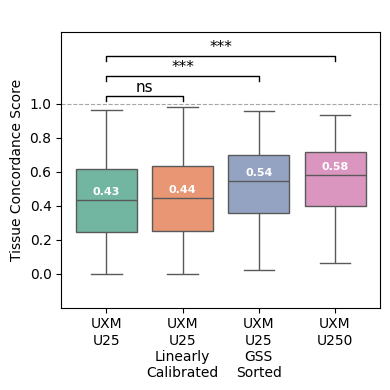

In [112]:
compare_methods_plot(
    uxm_tsc,
    uxm_tsc.columns[4:],
    show_points=False,
    baseline="UXM U25",
    figsize=(4, 4),
    kind="box",
    bracket_step=0.12,
    test="mannwhitney",
    show_ns=True,
    title=" ",
    ylabel="Tissue Concordance Score",
)

In [123]:
uxm_tsc

,file,Biosample term name,expected_cell_types,final_mapping_rate,UXM U25,UXM U25 Linearly Calibrated,UXM U250,UXM U25 GSS Sorted
0,GSM7427236,adipose tissue,"[Dermal-Fibro, Blood-T, Blood-Mono+Macro, Bloo...",0.9617,0.7277,0.7656,0.7676,0.5082
2,GSM7427238,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.1049,0.1047,0.2531,0.2495
3,GSM7427239,small intestine,"[Small-Int-Ep, Blood-T, Blood-B, Dermal-Fibro,...",0.9760,0.5994,0.6118,0.8051,0.8171
6,GSM7427242,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.2117,0.2413,0.2320,0.2154
7,GSM7427243,kidney,"[Kidney-Ep, Blood-T, Blood-B, Blood-Mono+Macro...",0.9892,0.6793,0.6831,0.6900,0.6358
...,...,...,...,...,...,...,...,...
449,GSM7427685,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.1594,0.1608,0.3329,0.2162
450,GSM7427686,pancreas,"[Pancreas-Acinar, Pancreas-Duct, Endothelium, ...",0.9488,0.7338,0.7473,0.6831,0.7139
452,GSM7427688,blood vessel,"[Dermal-Fibro, Smooth-Musc, Blood-Mono+Macro, ...",0.9457,0.2436,0.2386,0.5053,0.1804
458,GSM7427694,ovary,"[Ovary+Endom-Ep, Smooth-Musc, Endothelium]",0.9381,0.1952,0.2069,0.5012,0.5538


In [126]:
methylbert_soft_tsc = methylbert_soft_tsc.merge(uxm_tsc[["file", "UXM U25"]], on="file")

/tmp/ipykernel_364650/3608120701.py:122: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=long_df, x='method', y='value', order=order,


(<Axes: title={'center': ' '}, ylabel='Tissue Concordance Score'>,
        method       p_value annotation
 0    MLP_LCal  6.795165e-15        ***
 1         MLP  2.437213e-14        ***
 2         XGB  3.389095e-09        ***
 3    XGB_LCal  2.042211e-05        ***
 4         SWN  3.489157e-02          *
 5    SWN_LCal  1.113674e-01         ns
 6     UXM U25           NaN           
 7        PSLS  2.804407e-01         ns
 8   PSLS_LCal  1.301344e-01         ns
 9        NNLS  1.811111e-01         ns
 10  NNLS_LCal  8.550065e-02          .)

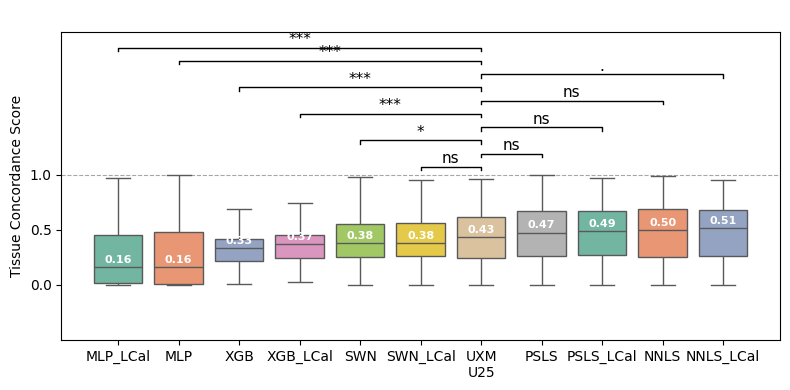

In [132]:
compare_methods_plot(
    methylbert_soft_tsc,
    methylbert_soft_tsc.columns[4:],
    show_points=False,
    baseline="UXM U25",
    figsize=(8, 4),
    kind="box",
    bracket_step=0.12,
    test="mannwhitney",
    show_ns=True,
    title=" ",
    ylabel="Tissue Concordance Score",
)

### Analysis of aggregated rrbs matrices

In [4]:
import os
import pickle

In [ ]:
deconvolutions_path = "/data/dmytro/Experiments/cfsort_rrbs/methylBert_Loyfer_205files_U25_attentionClassifier_hg38_dmr_ctype_label_mincpg_4_minlen_10_d041_postfiltered_min_length_50_soft_labels_pooled_jakkard/pseudobulk/deconvolutions/"

In [8]:
import os
import pickle
import pandas as pd
from pathlib import Path


def aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
):
    """
    For each per-file deconvolution result, identify DMR cell-type labels whose
    n_reads falls below each given threshold, count them, and collect the labels.

    Parameters
    ----------
    deconvolutions_path : str or Path
        Directory whose immediate subdirectories each contain `inner_filename`.
    thresholds : tuple of int
        Read-count thresholds. The first one is treated as exact equality
        (n_reads == 0); the rest as strict inequalities (n_reads < t).
        Adjust the rule below if you want a different convention.
    inner_filename : str
        Name of the pickle file inside each subdirectory.
    label_col, reads_col : str
        Column names in the loaded dataframe.
    verbose : bool
        Print a warning for files that fail to load or are missing columns.

    Returns
    -------
    pd.DataFrame
        One row per file with columns:
            file_name,
            count_eq_0, count_lt_5, count_lt_10, count_lt_30,
            labels_eq_0, labels_lt_5, labels_lt_10, labels_lt_30
        (column names follow the thresholds you pass in)
    """
    deconvolutions_path = Path(deconvolutions_path)

    # Build (column_suffix, predicate) for each threshold.
    # First threshold uses ==, others use <.
    rules = []
    for i, t in enumerate(thresholds):
        if i == 0:
            rules.append((f"eq_{t}", lambda s, t=t: s == t))
        else:
            rules.append((f"lt_{t}", lambda s, t=t: s < t))

    rows = []
    subdirs = sorted(p for p in deconvolutions_path.iterdir() if p.is_dir())

    for subdir in subdirs:
        pkl_path = subdir / inner_filename
        if not pkl_path.exists():
            if verbose:
                print(f"[skip] {subdir.name}: {inner_filename} not found")
            continue

        try:
            with open(pkl_path, "rb") as f:
                df = pickle.load(f)
        except Exception as e:
            if verbose:
                print(f"[skip] {subdir.name}: failed to load ({e})")
            continue

        if not isinstance(df, pd.DataFrame):
            if verbose:
                print(
                    f"[skip] {subdir.name}: pickle is {type(df).__name__}, not DataFrame"
                )
            continue
        if label_col not in df.columns or reads_col not in df.columns:
            if verbose:
                print(f"[skip] {subdir.name}: missing required columns")
            continue

        row = {"file_name": subdir.name}
        for suffix, predicate in rules:
            mask = predicate(df[reads_col])
            labels = df.loc[mask, label_col].tolist()
            row[f"count_{suffix}"] = int(mask.sum())
            row[f"labels_{suffix}"] = labels
        rows.append(row)

    # Preserve a sensible column order
    count_cols = [f"count_{suffix}" for suffix, _ in rules]
    label_cols = [f"labels_{suffix}" for suffix, _ in rules]
    result = pd.DataFrame(rows, columns=["file_name"] + count_cols + label_cols)
    return result

In [9]:
aggregated_stats = aggregate_low_coverage_dmrs(
    deconvolutions_path,
    thresholds=(0, 5, 10, 30),
    inner_filename="dmr_aggregated.pkl",
    label_col="dmr_ctype_label",
    reads_col="n_reads",
    verbose=True,
)

In [24]:
methylbert_soft_tsc

,file,Biosample term name,expected_cell_types,final_mapping_rate,XGB,XGB_LCal,MLP,MLP_LCal,SWN,SWN_LCal,NNLS,NNLS_LCal,PSLS,PSLS_LCal
0,GSM7427236,adipose tissue,"[Dermal-Fibro, Blood-T, Blood-Mono+Macro, Bloo...",0.9617,0.5201,0.5442,0.0000,0.0111,0.4377,0.4348,0.6656,0.6806,0.6537,0.6743
2,GSM7427238,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.1272,0.1482,0.0000,0.0109,0.0214,0.0275,0.0000,0.0142,0.0000,0.0138
3,GSM7427239,small intestine,"[Small-Int-Ep, Blood-T, Blood-B, Dermal-Fibro,...",0.9760,0.4299,0.4501,0.2607,0.2535,0.8877,0.8679,0.9350,0.9042,0.9213,0.8945
6,GSM7427242,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.0838,0.1061,0.0000,0.0109,0.2729,0.2573,0.0954,0.1053,0.1042,0.1149
7,GSM7427243,kidney,"[Kidney-Ep, Blood-T, Blood-B, Blood-Mono+Macro...",0.9892,0.3056,0.3137,0.4758,0.4519,0.4251,0.4466,0.6985,0.6806,0.6487,0.6335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
449,GSM7427685,skin,"[Blood-T, Dermal-Fibro, Blood-Mono+Macro, Bloo...",0.9655,0.3504,0.3916,0.0041,0.0149,0.3644,0.3431,0.2573,0.2559,0.2574,0.2587
450,GSM7427686,pancreas,"[Pancreas-Acinar, Pancreas-Duct, Endothelium, ...",0.9488,0.4269,0.4490,0.3657,0.3477,0.7689,0.7546,0.8743,0.8387,0.8434,0.8127
452,GSM7427688,blood vessel,"[Dermal-Fibro, Smooth-Musc, Blood-Mono+Macro, ...",0.9457,0.3918,0.4429,0.0177,0.0282,0.3112,0.3287,0.3720,0.3911,0.3475,0.3657
458,GSM7427694,ovary,"[Ovary+Endom-Ep, Smooth-Musc, Endothelium]",0.9381,0.0546,0.0790,0.0000,0.0085,0.0000,0.0033,0.0000,0.0022,0.0000,0.0030


In [26]:
aggregated_stats["file_name"] = aggregated_stats["file_name"].apply(
    lambda x: x.split("_")[0]
)

In [32]:
aggregated_stats

,file_name,count_eq_0,count_lt_5,count_lt_10,count_lt_30,labels_eq_0,labels_lt_5,labels_lt_10,labels_lt_30
0,GSM7427236,3,4,4,7,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 9, 11, 15, 16, 19, 37]"
1,GSM7427237,2,4,4,6,"[11, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 10, 11, 15, 16, 37]"
2,GSM7427238,3,4,4,6,"[11, 16, 37]","[0, 11, 16, 37]","[0, 11, 16, 37]","[0, 11, 15, 16, 32, 37]"
3,GSM7427239,2,3,3,6,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[0, 10, 11, 15, 16, 37]"
4,GSM7427240,1,2,3,5,[11],"[11, 37]","[0, 11, 37]","[0, 11, 15, 16, 37]"
...,...,...,...,...,...,...,...,...,...
516,GSM7427756,3,3,3,5,"[11, 16, 37]","[11, 16, 37]","[11, 16, 37]","[0, 11, 15, 16, 37]"
517,GSM7427757,1,2,2,3,[11],"[11, 37]","[11, 37]","[11, 16, 37]"
518,GSM7427758,2,3,3,4,"[11, 37]","[11, 16, 37]","[11, 16, 37]","[11, 15, 16, 37]"
519,GSM7427759,1,2,2,2,[11],"[11, 37]","[11, 37]","[11, 37]"


In [34]:
aggregated_stats[
    aggregated_stats["file_name"].apply(
        lambda x: x in methylbert_soft_tsc["file"].to_list()
    )
].count_lt_30.value_counts()

count_lt_30
5    142
6     96
4     17
7      3
2      1
3      1
Name: count, dtype: int64